# User Manual

`ethograph` visualizes behavioural recordings across modalities:

| Data | Shown as | File formats / loaders |
|------|----------|------------------------|
| **Video** | Napari viewer | `.mp4`, `.mov`, ...  (via [pyav](https://pyav.org/docs/stable/))|
| **Pose/ BoundingBox** | Overlay on video | `.h5`, `.csv` (DLC, SLEAP, LightningPose, ... via [movement](https://movement.neuroinformatics.dev)) |
| **Audio** | Waveform + spectrogram | `.wav`, `.mp3` (via [audioio](https://github.com/bendalab/audioio)) |
| **Electrophysiology** | Multi-channel trace | `.rhd`, `.abf`, `.dat`, ... (via [Neo](https://neo.readthedocs.io) & and [phylib](https://github.com/cortex-lab/phylib)) |
| **Spike-sorted units** | Raster / PSTH | [Kilosort](https://github.com/MouseLand/Kilosort) folder, `.nwb` file, {class}`pynapple.TsGroup`|
| **Features** | Lineplot / heatmap | Kinematics, firing rates, latent variables, model outputs, ... |

---


Feature data can be loaded via three backends:

| Backend | Object | File format |
|---------|--------|-------------|
| **xarray** | {class}`xarray.Dataset` / {class}`~ethograph.io.trialtree.TrialTree` | `.nc` |
| **Pynapple** | {class}`~pynapple.Tsd` / {class}`~pynapple.TsdFrame` | `.npz` or folder |
| **NWB** | `.nwb` (loaded via {mod}`pynapple`) | `.nwb` |

Unlike a plain numpy array, all three formats carry explicit timestamps with each value.
This allows `ethograph` to automatically align data of different sampling rates and
modalities (video, audio & electrophysiology).


## Feature dropdowns

To showcase some `ethograph` functionalities, we will use pose data from a carrion crow performing a tool-use task (Moll et al., 2025¹). The {class}`xarray.Dataset` is from one behavioural trial, and shows position, velocity, speed, and acceleration for 3 keypoints tracked in 3D.




In [ ]:
import ethograph as eto

ds = eto.sample_data()
ds[["position", "velocity", "speed"]] 

<xarray.Dataset> Size: 206kB
Dimensions:      (time: 1169, space: 3, keypoints: 3, individuals: 1)
Coordinates:
  * time         (time) float64 9kB 0.0 0.005 0.01 0.015 ... 5.83 5.835 5.84
  * space        (space) <U1 12B 'x' 'y' 'z'
  * keypoints    (keypoints) <U8 96B 'beakTip' 'stickTip' 'pellet'
  * individuals  (individuals) <U5 20B 'Crow1'
Data variables:
    position     (time, space, keypoints, individuals) float64 84kB ...
    velocity     (time, space, keypoints, individuals) float64 84kB ...
    speed        (time, keypoints, individuals) float64 28kB ...
Attributes:
    source_software:  DeepLabCut
    ds_type:          poses
    fps:              200.0
    time_unit:        seconds
    source_file:      C:/Users/aksel/Documents/Code/EthoGraph/data/Moll2025/2...
    trial:            115
    bird:             Crow1
    session_date:     2024-12-17
    pellet_position:  left
    human_verified:   1

<br>
<br>
Notice the dimensions:

| Feature | Dimensions |
|---------|------------|
| `position` | `(time, space, keypoints, individuals)` |
| `velocity` | `(time, space, keypoints, individuals)` |
| `speed` | `(time, keypoints, individuals)` |



<br>
<br>

With {class}`xarray.DataArray`, you can use {meth}`~xarray.DataArray.sel` to pick
a specific keypoint, spatial axis, and individual:

In [ ]:

# Standard xarray .sel — works when all dimensions exist
beak_x = ds["position"].sel(keypoints="beakTip", space="x", individuals="Crow1")
print(f"position with .sel: shape {beak_x.shape}")

# But speed has no 'space' dimension — .sel raises an error:
try:
    ds["speed"].sel(keypoints="beakTip", space="x", individuals="Crow1")
except (KeyError, ValueError) as e:
    print(f"speed with .sel:   {type(e).__name__}: {e}")

position with .sel: shape (1169,)
speed with .sel:   KeyError: "'space' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'time': 1169, 'keypoints': 3, 'individuals': 1})"


<br>

---

<br>

In the GUI, you can switch between features using the **Feature** dropdown and **select** ({meth}`~xarray.DataArray.sel`) a unique combination of feature dimensions. In the video below, the user switches from the feature `speed` to `velocity`, with the selection dimensions `individuals=crow1`, `keypoints=beakTip` and `space=["x", "y", "z"]` (All checkbox ticked). Thanks to {func}`~ethograph.sel_valid`, any invalid dimensions are ignored (e.g. it's not problematic that speed does not have a `space` dimension).

<video controls loop muted autoplay width="100%">
  <source src="../_static/videos/dropdown.mp4" type="video/mp4">
</video>



<br>
<br>

At the end of the video and in the plot below, one can see that particularly `velocity` for `keypoints=beakTip` and `space=z` (green line) defines segmentation boundaries of the crows downward movement, inserting the stick tool into the dispenser.

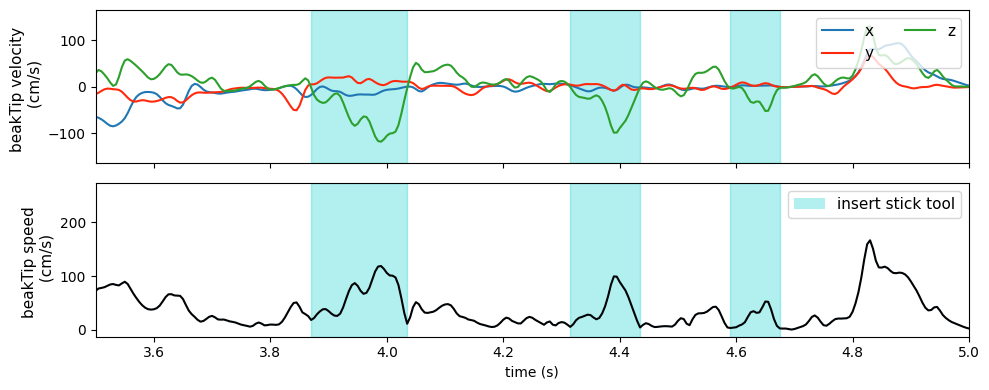

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ethograph.labels.intervals import add_interval, empty_intervals
from ethograph.labels.plots import plot_label_segments

sel = {"keypoints": "beakTip", "individuals": "Crow1"}

# 3 labelled intervals (real onsets from the Moll2025 dataset)
label_color = np.array([0, 204, 204]) / 255.0  # _LABEL_COLORS[10]
labels_df = empty_intervals()
labels_df = add_interval(labels_df, 3.87, 4.035, 10, "Crow1")
labels_df = add_interval(labels_df, 4.315, 4.435, 10, "Crow1")
labels_df = add_interval(labels_df, 4.588757756, 4.674700055, 10, "Crow1")

label_mappings = {10: {"name": "stickInDisp", "color": label_color, "order": 10, "branch": 0}}

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

# velocity x, y, z
for i, (axis_name, color) in enumerate(zip(["x", "y", "z"], ["#1f77b4", "#ff2a0e", "#2ca02c"])):
    vel, _ = eto.sel_valid(ds["velocity"].sel(space=axis_name), sel)
    axes[0].plot(ds.time, vel, color=color, label=axis_name)
axes[0].set_ylabel("beakTip velocity \n (cm/s)", fontsize=11)
axes[0].legend(loc="upper right", fontsize=11, ncol=2)
plot_label_segments(axes[0], labels_df, label_mappings, individual="Crow1", is_main=True, alpha=0.3)

# speed
spd, _ = eto.sel_valid(ds["speed"], sel)
axes[1].plot(ds.time, spd, color="#000305")
axes[1].set_ylabel("beakTip speed \n (cm/s)", fontsize=11)
plot_label_segments(axes[1], labels_df, label_mappings, individual="Crow1", is_main=True, alpha=0.3)

axes[1].set_xlabel("time (s)")
insert_stick_patch = mpatches.Patch(
    facecolor=label_color,
    alpha=0.3,
    edgecolor="none",
    label="insert stick tool",
)

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(
    [insert_stick_patch],
    ["insert stick tool"],
    loc="upper right",
    fontsize=11,
    ncol=4,
)

for ax in axes:
    ax.set_xlim(3.5, 5.0)



plt.tight_layout()
plt.show()

## Changepoints

Besides looking at the `z-velocity`, one can also identify good candidates for semgentation boundaries by looking at where there are minima or turnings points in the `beakTip` speed curve. We call these kinematic `/user_guide/changepoints`.


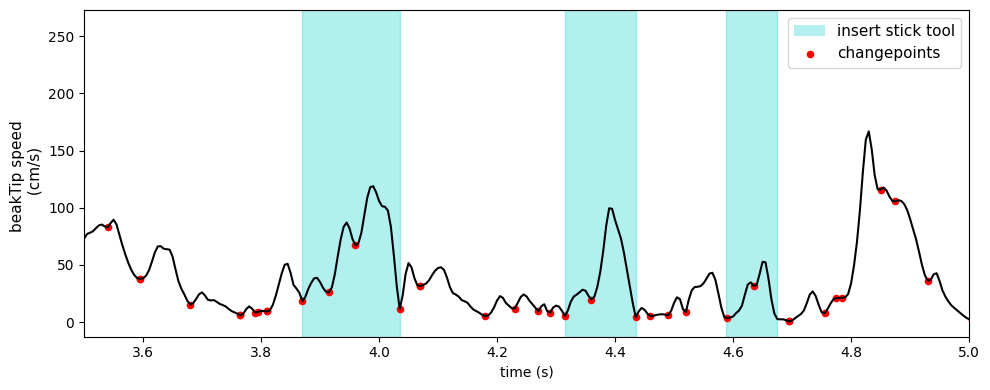

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from ethograph.labels.intervals import add_interval, empty_intervals
from ethograph.labels.plots import plot_label_segments

sel = {"keypoints": "beakTip", "individuals": "Crow1"}

# 3 labelled intervals (real onsets from the Moll2025 dataset)
label_color = np.array([0, 204, 204]) / 255.0  # _LABEL_COLORS[10]
labels_df = empty_intervals()
labels_df = add_interval(labels_df, 3.87, 4.035, 10, "Crow1")
labels_df = add_interval(labels_df, 4.315, 4.435, 10, "Crow1")
labels_df = add_interval(labels_df, 4.588757756, 4.674700055, 10, "Crow1")

label_mappings = {10: {"name": "stickInDisp", "color": label_color, "order": 10, "branch": 0}}

fig = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

# speed
spd, _ = eto.sel_valid(ds["speed"], sel)
plt.plot(ds.time, spd, color="#000305")

troughs = ds["speed_troughs"].sel(keypoints="beakTip", individuals="Crow1").values
trough_idx = np.where(troughs == 1)[0]
turning_points = ds["speed_turning_points"].sel(keypoints="beakTip", individuals="Crow1").values
turning_points_idx = np.where(turning_points == 1)[0]
changepoints_idx = np.sort(np.concatenate([trough_idx, turning_points_idx]))
plt.scatter(ds.time[changepoints_idx], spd[changepoints_idx], s=20, c="r", label="changepoints")
plt.ylabel("beakTip speed \n (cm/s)", fontsize=11)
plot_label_segments(plt, labels_df, label_mappings, individual="Crow1", is_main=True, alpha=0.3)

plt.xlabel("time (s)")
insert_stick_patch = mpatches.Patch(
    facecolor=label_color,
    alpha=0.3,
    edgecolor="none",
    label="insert stick tool",
)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    [insert_stick_patch, *handles],
    ["insert stick tool", *labels],
    loc="upper right",
    fontsize=11,
)

plt.xlim(3.5, 5.0)
plt.tight_layout()
plt.show()

## Building a TrialTree

A single {class}`xarray.Dataset` holds one trial. A {class}`~ethograph.io.trialtree.TrialTree` wraps multiple
trials into one object:

In [5]:
# Wrap as a TrialTree (here just one trial for demo)
dt = eto.from_datasets([ds])

print(f"Trials: {dt.trials}")
print(f"Trial at index 0: {dt.itrial(0).attrs['trial']}")
print(f"Features: {list(dt.trial(dt.trials[0]).data_vars)[:5]}...")

Trials: [115]
Trial at index 0: 115
Features: ['position', 'confidence', 'velocity', 'speed', 'acceleration']...


## Data requirements summary

| | xarray | Pynapple | NWB |
|--|--------|----------|-----|
| **File format** | `.nc` via {class}`~ethograph.io.trialtree.TrialTree` | `.npz` or folder | `.nwb` |
| **Required attrs** | `trial`, `fps` | *(none)* | *(NWB standard)* |
| **Features** | Any `data_var` with a time dim | Any {class}`~pynapple.Tsd` / {class}`~pynapple.TsdFrame` | {class}`~pynwb.TimeSeries` in processing |
| **Individuals** | `coords["individuals"]` | Separate objects | One subject per file |
| **Trials** | One `Dataset` per trial | {class}`~pynapple.IntervalSet` | `nwb.trials` table |

See [Data Format Requirements](data_requirements.md) for full specifications
across all three backends.

## Operations across backends

| Operation | xarray / TrialTree | Pynapple | NWB |
|-----------|-------------------|----------|-----|
| **Load** | {func}`~ethograph.open` | {func}`~ethograph.load_nap_data` | {func}`~ethograph.load_nap_data` |
| **Restrict** | {meth}`~xarray.Dataset.sel` | {meth}`~pynapple.Tsd.restrict` | Via {mod}`pynapple` |
| **Select dims** | {func}`~ethograph.sel_valid` | Column indexing on {class}`~pynapple.TsdFrame` | Via {mod}`pynapple` |
| **Build** | {func}`~ethograph.from_datasets` | {func}`~pynapple.save_file` | {class}`~pynwb.NWBHDF5IO` |
| **Alignment** | `.ethograph/alignment.nwb` | `.ethograph/alignment.nwb` | In source `.nwb` |
| **Iterate trials** | {meth}`~ethograph.io.trialtree.TrialTree.trial_items` | {meth}`~pynapple.Tsd.restrict` | Via {mod}`pynapple` |

### References

Moll, F. W., Würzler, J., & Nieder, A. (2025). Learned precision tool use in carrion crows. Current Biology, 35(19), 4845-4852.e3. https://doi.org/10.1016/j.cub.2025.08.033